# Решение домашнего задания #25

[задача](../../tasks/hometask_25.ipynb)

In [1]:
import glob
import os

import torch
import cv2

from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration
from datasets import load_dataset

import matplotlib.pyplot as plt

from tam import TAM

# Настройки
os.makedirs('vis_results', exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

2025-12-17 08:44:07.786503: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda


In [2]:
SAMPLE_SIZE = 10

## Загрузка модели LLaVA-NeXT

Используем **LLaVA-NeXT (LLaVA-v1.6-Mistral-7B)** - улучшенную версию LLaVA с лучшим пониманием текста в изображениях.

In [3]:
# Загрузка модели LLaVA-NeXT (v1.6)
model_name = "llava-hf/llava-v1.6-mistral-7b-hf"

model = LlavaNextForConditionalGeneration.from_pretrained(
    model_name, 
    device_map="auto",
    low_cpu_mem_usage=True,
    dtype=torch.float16,
)

processor = LlavaNextProcessor.from_pretrained(model_name, use_fast=True)

print(f"Model uses: {model.dtype}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model uses: torch.float16


## Загрузка датасета TextVQA

Используем **TextVQA** - датасет с изображениями, содержащими объектами, о которых нужно отвечать на вопросы. Это специфический датасет, не представленный в demo TAM. Мы будем просить модель **обосновывать** свои ответы, чтобы увидеть куда направлено внимание при рассуждении.

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Dataset contains 10 samples


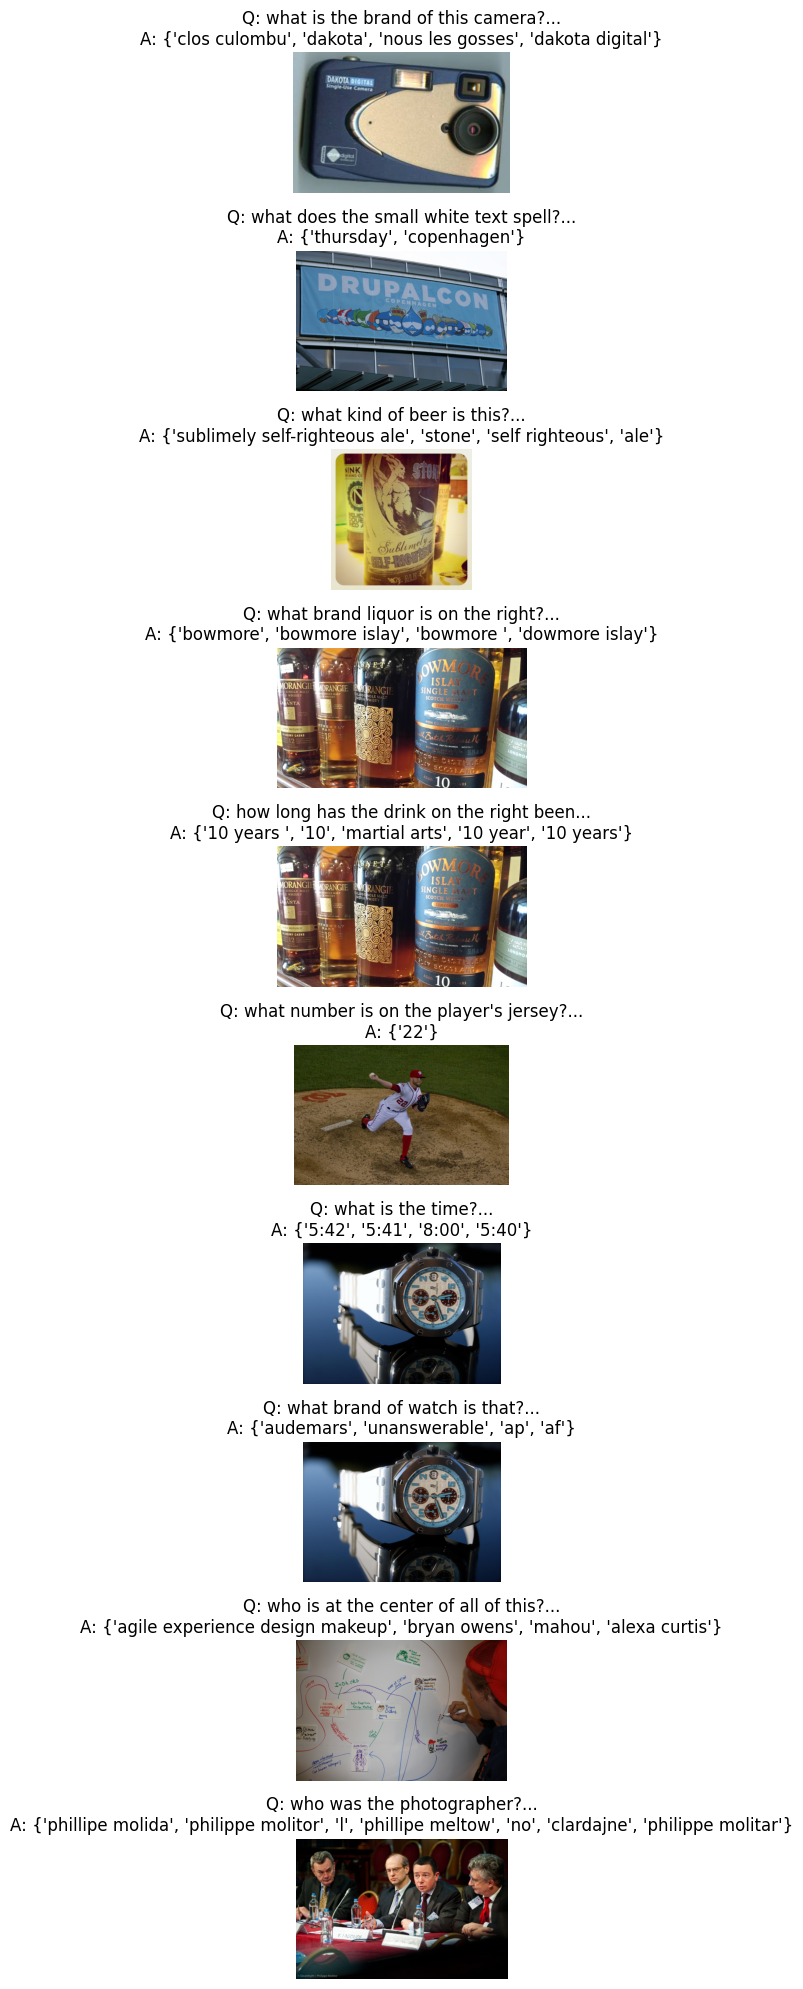

In [4]:
textvqa_dataset = load_dataset("lmms-lab/textvqa", split="validation")[:SAMPLE_SIZE]

print(f"Dataset contains {SAMPLE_SIZE} samples")

# Sampling visualization
fig, axes = plt.subplots(SAMPLE_SIZE, 1, figsize=(12, 20))
for idx, (image, question, answers) in enumerate(zip(textvqa_dataset['image'], textvqa_dataset['question'], textvqa_dataset['answers'])):
    axes[idx].imshow(image)
    axes[idx].set_title(f"Q: {question[:40]}...\nA: {set(answers)}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Применение TAM для визуализации

In [5]:
def apply_tam_to_llava_next(image, question, save_dir='vis_results', ask_reasoning=True):
    # Making prompt
    if ask_reasoning:
        messages = [  
            {  
                "role": "user",  
                "content": [
                    { "type": "image" }, 
                    { "type": "text", "text": f"{question} Please explain your reasoning." },  
                ]  
            }  
        ] 
    else:
        messages = [  
            {  
                "role": "user",  
                "content": [
                    { "type": "image" },
                    { "type": "text", "text": f"{question}"},  
                ]  
            }  
        ] 
    
    # Input processing
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(image, prompt, return_tensors="pt").to(model.device)
    
    print(f"Question: '{question}'")
    print(f"Input tokens shape: {inputs['input_ids'].shape}")
    
    # Generation with hidden states
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        return_dict_in_generate=True,
        output_scores=True,
        do_sample=False  # greedy decoding
    )
    
    generated_ids = outputs.sequences
    generated_text = processor.batch_decode(
        generated_ids, 
        skip_special_tokens=True, 
        clean_up_tokenization_spaces=True
    )[0]
    
    input_logits = model(**inputs)
    
    print(f"Model answer: {generated_text}")
    
    logits = [torch.cat((input_logits.logits[0],) + outputs.scores).unsqueeze(0)]
    
    # Special tokens for LLaVA-NeXT
    input_ids_list = inputs['input_ids'][0].cpu().tolist()
    
    # For LLaVA-NeXT image token 
    image_token_id = processor.tokenizer.convert_tokens_to_ids("<image>")
    print(inputs)
    
    print(f"Image token ID: {image_token_id}")
    
    # Finding the position of the image token
    img_token_positions = [i for i, token_id in enumerate(input_ids_list) if token_id == image_token_id]
    
    if len(img_token_positions) == 0:
        print("WARNING: Image token not found, using default positions")
        img_start_idx = 5
        num_image_tokens = 576  # 24x24 for LLaVA
    else:
        img_start_idx = img_token_positions[0]
        # LLaVA-NeXT may have a different number of tokens
        num_image_tokens = 576  # standard for LLaVA-NeXT
    
    print(f"Image tokens: start={img_start_idx}, count={num_image_tokens}")
    
    # Special IDs for TAM
    special_ids = {
        'img_id': [0, num_image_tokens],
        'prompt_id': [num_image_tokens, len(input_ids_list)],
        'answer_id': [len(input_ids_list), -1]
    }
    
    # Shape of visual tokens
    vision_shape = (24, 24)
    
    # Applying TAM
    print(f"Applying TAM for visualization...")
    raw_map_records = []
    
    # Generating visualization for several tokens
    num_rounds = min(5, len(logits))
    for i in range(num_rounds):
        output_path = os.path.join(save_dir, f'tam_round_{i}.jpg')
        
        try:
            img_map = TAM(
                generated_ids[0].cpu().tolist(),
                vision_shape,
                logits,
                special_ids,
                [image],
                processor,
                output_path,
                i,
                raw_map_records,
                eval_only=False
            )
            print(f"+ Round {i} saved")
        except Exception as e:
            print(f"- Error in round {i}: {e}")
            if i == 0:  # Show full traceback only for the first error
                import traceback
                traceback.print_exc()
    
    return generated_text, raw_map_records

answers = []
maps = []

for idx, (image, question, answers) in enumerate(zip(textvqa_dataset['image'], textvqa_dataset['question'], textvqa_dataset['answers'])):
    answer, map_records = apply_tam_to_llava_next(image, question, ask_reasoning=True)
    answers.append(answer)
    maps.append(map_records)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Question: 'what is the brand of this camera?'
Input tokens shape: torch.Size([1, 2168])
Model answer: [INST]  
what is the brand of this camera? Please explain your reasoning. [/INST] The brand of the camera in the image is "Dakota Digital." This is evident from the text on the camera's body. Dakota Digital is a company that specializes in automotive electronics, including digital gauges and other vehicle-related products. However, they also produce a line of single-lens reflex (SLR) cameras, which are digital cameras that use interchangeable lenses. The camera in the image is one of their SLR models. 
{'input_ids': tensor([[    1,   733, 16289,  ..., 28748, 16289, 28793]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[ 0.6603,  0.6603,  0.6603,  ...,  0.3099,  0.3099,  0.3099],
           [ 0.6603,  0.6603,  0.6603,  ...,  0.3099,  0.3099,  0.3099],
           [ 0.6603,  0.6603,  0.6603,  ...,  0.3099,  0.3099,  0.

Traceback (most recent call last):
  File "/tmp/ipykernel_2437711/3105301789.py", line 96, in apply_tam_to_llava_next
    img_map = TAM(
              ^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 539, in TAM
    img_map = TAM(tokens, vision_shape, logit_list, special_ids, vision_input, processor, \
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 626, in TAM
    vis_img, img_map = multimodal_process(cv_img, vision_shape, img_scores, txt_scores, txt_all, candidates, candi_scores, vis_token_idx, \
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 344, in multimodal_process
    img_scores = rank_guassian_filter(img_scores.reshape(t_h, t_w), 3)
                                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Value

(2267,)
(2267,) (4535,)
(2267,) (4535,)
(2267,)
- Error in round 0: cannot reshape array of size 2267 into shape (24,24)
Question: 'what does the small white text spell?'
Input tokens shape: torch.Size([1, 2168])
Model answer: [INST]  
what does the small white text spell? Please explain your reasoning. [/INST] The small white text at the bottom of the banner spells "COPENHAGEN." This is likely the location of the DrupalCon event, as indicated by the text above it. The banner is advertising DrupalCon, which is a conference for the Drupal community, and the location is specified as Copenhagen. 
{'input_ids': tensor([[    1,   733, 16289,  ..., 28748, 16289, 28793]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[-9.4555e-01, -8.7256e-01, -8.8716e-01,  ...,  1.8281e+00,
             1.8281e+00,  1.8281e+00],
           [-8.7256e-01, -8.4336e-01, -8.4336e-01,  ...,  1.8281e+00,
             1.8281e+00,  1.8281e+00],
   

Traceback (most recent call last):
  File "/tmp/ipykernel_2437711/3105301789.py", line 96, in apply_tam_to_llava_next
    img_map = TAM(
              ^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 539, in TAM
    img_map = TAM(tokens, vision_shape, logit_list, special_ids, vision_input, processor, \
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 626, in TAM
    vis_img, img_map = multimodal_process(cv_img, vision_shape, img_scores, txt_scores, txt_all, candidates, candi_scores, vis_token_idx, \
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 344, in multimodal_process
    img_scores = rank_guassian_filter(img_scores.reshape(t_h, t_w), 3)
                                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Value

...

Traceback (most recent call last):
  File "/tmp/ipykernel_2437711/3105301789.py", line 96, in apply_tam_to_llava_next
    img_map = TAM(
              ^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 539, in TAM
    img_map = TAM(tokens, vision_shape, logit_list, special_ids, vision_input, processor, \
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 626, in TAM
    vis_img, img_map = multimodal_process(cv_img, vision_shape, img_scores, txt_scores, txt_all, candidates, candi_scores, vis_token_idx, \
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 344, in multimodal_process
    img_scores = rank_guassian_filter(img_scores.reshape(t_h, t_w), 3)
                                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Value

Question: 'who is at the center of all of this?'
Input tokens shape: torch.Size([1, 2170])
Model answer: [INST]  
who is at the center of all of this? Please explain your reasoning. [/INST] The image shows a person writing on a whiteboard with various sticky notes and drawings attached to it. The person appears to be engaged in a brainstorming or planning session, possibly related to a project or a team meeting. The sticky notes contain text and drawings, which seem to be ideas or tasks being organized or discussed.

At the center of all this activity, it's likely that the person is the one leading the discussion or the one responsible for organizing the ideas and
{'input_ids': tensor([[    1,   733, 16289,  ..., 28748, 16289, 28793]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[-0.7704, -0.8142, -0.7120,  ..., -0.4054, -0.3908, -0.3616],
           [-0.7120, -0.7558, -0.7120,  ..., -0.3324, -0.3616, -0.3616],
   

Traceback (most recent call last):
  File "/tmp/ipykernel_2437711/3105301789.py", line 96, in apply_tam_to_llava_next
    img_map = TAM(
              ^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 539, in TAM
    img_map = TAM(tokens, vision_shape, logit_list, special_ids, vision_input, processor, \
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 626, in TAM
    vis_img, img_map = multimodal_process(cv_img, vision_shape, img_scores, txt_scores, txt_all, candidates, candi_scores, vis_token_idx, \
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 344, in multimodal_process
    img_scores = rank_guassian_filter(img_scores.reshape(t_h, t_w), 3)
                                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Value

Question: 'who was the photographer?'
Input tokens shape: torch.Size([1, 2165])
Model answer: [INST]  
who was the photographer? Please explain your reasoning. [/INST] The image you've provided appears to be a photograph taken at a formal event, possibly a conference or a panel discussion. The text "© Gleamlight / Philippe Motteur" indicates that the photographer is Philippe Motteur from Gleamlight, a photography agency. The presence of the watermark suggests that the photographer has copyrighted the image and that it is being used with permission. The watermark is a common practice in professional photography to protect the rights of the photographer and to identify
{'input_ids': tensor([[    1,   733, 16289,  ..., 28748, 16289, 28793]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[-1.7923, -1.7923, -1.7923,  ..., -1.4857, -1.4857, -1.4857],
           [-1.7923, -1.7923, -1.7777,  ..., -1.4857, -1.4857, -1.4857],


Traceback (most recent call last):
  File "/tmp/ipykernel_2437711/3105301789.py", line 96, in apply_tam_to_llava_next
    img_map = TAM(
              ^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 539, in TAM
    img_map = TAM(tokens, vision_shape, logit_list, special_ids, vision_input, processor, \
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 626, in TAM
    vis_img, img_map = multimodal_process(cv_img, vision_shape, img_scores, txt_scores, txt_all, candidates, candi_scores, vis_token_idx, \
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home2/teststudent/MMMFinalProject/test/tam.py", line 344, in multimodal_process
    img_scores = rank_guassian_filter(img_scores.reshape(t_h, t_w), 3)
                                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Value

## Анализ результатов

In [6]:
visualization_samples = [(textvqa_dataset[i]['image'], maps[i], answers[i]) for i in range(len(answers))]

fig, axes = plt.subplots(3, len(visualization_samples), figsize=(6 * len(visualization_samples), 6))

for idx, (image, question, answers) in enumerate(zip(textvqa_dataset['image'], textvqa_dataset['question'], textvqa_dataset['answers'])):
    axes[0, idx].imshow(map_records[0]['raw_map'] + 0.5 * image)
    axes[1, idx].imshow(map_records[len(map_records) // 2]['raw_map'] + 0.5 * image)
    axes[2, idx].imshow(map_records[-1]['raw_map'] + 0.5 * image)

    axes[0, idx].set_title(f'A: {answer[:20]}...')
    axes[0, idx].axis('off')

plt.tight_layout()
plt.show()

KeyError: 0

## Эксперимент с разными промптами

In [ ]:
experiments = [
    {
        'title': 'NoReasoning',
        'ask_reasoning': False,
    },
    {
        'title': 'Reasoning',
        'ask_reasoning': True,
    }
]

all_results = {}

for exp in experiments:
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {exp['title']}")
    print(f"{'='*70}\n")
    
    for idx, (image, question, answers) in enumerate(zip(textvqa_dataset['image'], textvqa_dataset['question'], textvqa_dataset['answers'])):
        image_path = f"vis_results/textvqa_sample_{idx}.jpg"
        image.save(image_path)
        
        save_dir = f"vis_results/exp_{exp['title'].replace(' ', '_')}_img{idx}"
        os.makedirs(save_dir, exist_ok=True)
        
        print(f"\n--- Image {idx+1} ---")
        print(f"Question: {question}")
        print(f"Ground Truth: {set(answers)}")
        
        try:
            answer, _ = apply_tam_to_llava_next(
                image_path, 
                question, 
                save_dir,
                ask_reasoning=exp['ask_reasoning']
            )
            
            key = f"{exp['title']}_img{idx}"
            all_results[key] = {
                'question': question,
                'answer': answer,
                'ground_truth': set(answers)
            }
        except Exception as e:
            print(f"Error: {e}")
            all_results[f"{exp['title']}_img{idx}"] = {'error': str(e)}


for key, result in all_results.items():
    print(f"\n{key}:")
    if 'error' in result:
        print(f"  ERROR: {result['error']}")
    else:
        print(f"  Q: {result['question']}")
        print(f"  GT: {result['ground_truth']}")
        print(f"  Model: {result['answer'][:200]}...")

In [ ]:
for exp in experiments:
    fig, axes = plt.subplots(SAMPLE_SIZE, 1, figsize=(12, 20))
    for idx in range(SAMPLE_SIZE):
        key = f"{exp['title']}_img{idx}"
        image = textvqa_dataset[idx]['image']
        question = all_results[key]['question']
        answer = all_results[key]['answer']
        
        axes[idx].imshow(image)
        axes[idx].set_title(f"Q: {question[:40]}...\nA: {answer[:100]}...")
        axes[idx].axis('off')
    
    plt.suptitle(f"Experiment: {exp['title']}", fontsize=16)
    plt.tight_layout()
    plt.show()